# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 05: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_06_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O Iranian Churn Dataset pertence ao domínio de telecomunicações e análise de clientes, sendo utilizado em problemas de previsão de churn, ou seja, identificação de clientes com maior probabilidade de cancelar um serviço. O objetivo da base de dados é auxiliar no desenvolvimento de modelos de aprendizado de máquina capazes de prever o cancelamento de clientes a partir de características de uso e comportamento. O dataset contém informações relacionadas ao perfil e utilização do serviço pelos clientes, incluindo número de reclamações, tempo de assinatura, frequência de uso, quantidade de SMS enviados, duração de chamadas, valor do cliente e outros atributos operacionais.

In [3]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [6]:
#Exibir primeiras linhas
print(df.head())

#Dimensões do dataframe
print("Dimensões:", df.shape)

#Variável alvo
TARGET_COLUMN = "Churn"
print("Variável alvo:", TARGET_COLUMN)

#Valores únicos da variável alvo
print("Valores únicos:", df[TARGET_COLUMN].unique())

   Call  Failure  Complains  Subscription  Length  Charge  Amount  \
0              8          0                    38               0   
1              0          0                    39               0   
2             10          0                    37               0   
3             10          0                    38               0   
4              3          0                    38               0   

   Seconds of Use  Frequency of use  Frequency of SMS  \
0            4370                71                 5   
1             318                 5                 7   
2            2453                60               359   
3            4198                66                 1   
4            2393                58                 2   

   Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
0                       17          3            1       1   30   
1                        4          2            1       2   25   
2                       24          3    

In [ ]:
TARGET_COLUMN = Churn # preencher


#O problema é de classificação binária, pois a variável alvo possui apenas dois valores únicos: [0, 1]. Ou seja existem somente duas classes possíveis.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

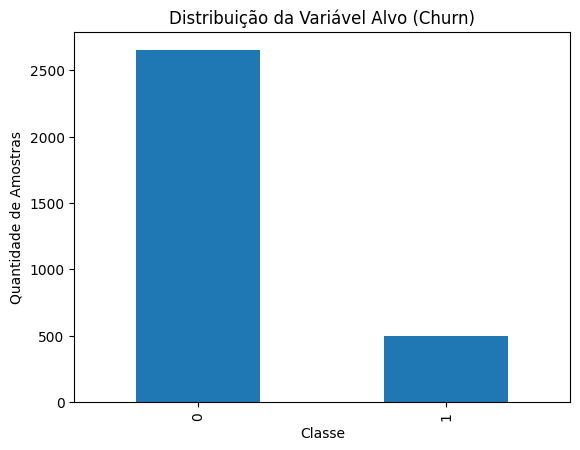

Churn
0    2655
1     495
Name: count, dtype: int64


In [7]:
#Contagem das classes
class_counts = df[TARGET_COLUMN].value_counts()

#Plotar gráfico
class_counts.plot(kind='bar')

#Configurações do gráfico
plt.title("Distribuição da Variável Alvo (Churn)")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Amostras")

plt.show()

#Exibir contagem
print(class_counts)

o dataset é desbalanceado pois a classe 0 possui 2655 amostras, enquanto a classe 1 possui 495 amostras. Mostrando que há uma grande diferença entre as quantidades de exemplos de cada classe.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

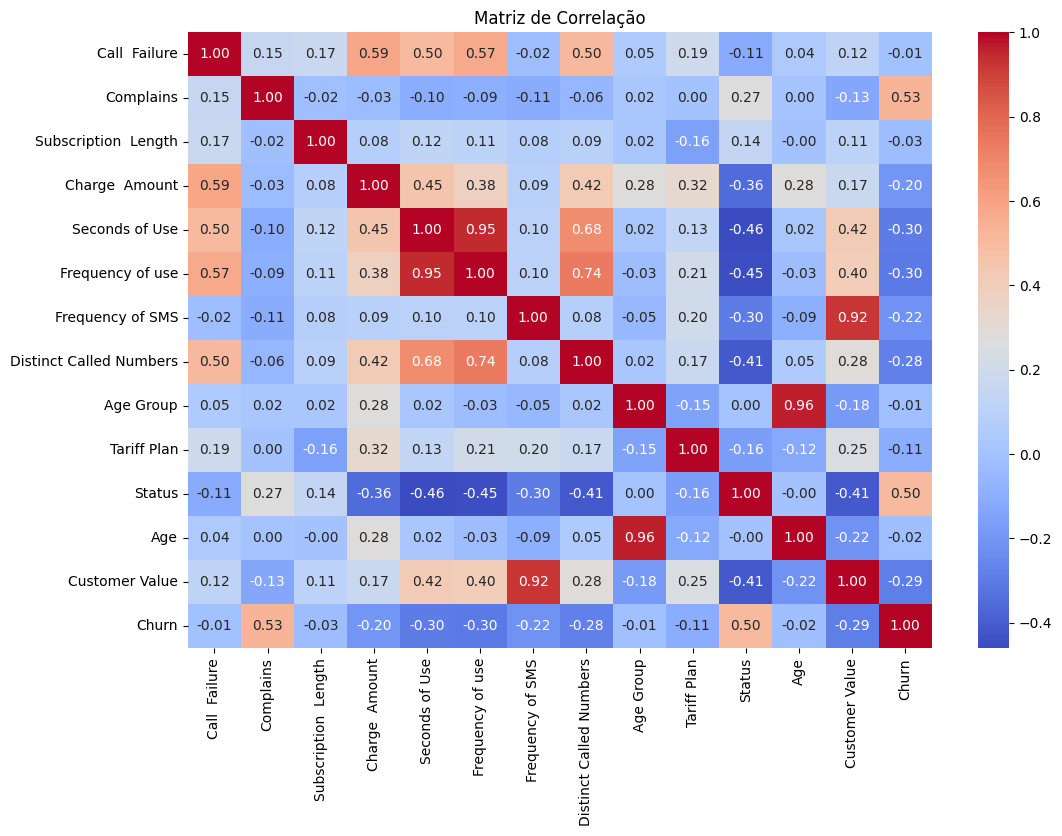

In [8]:
#Matriz de correlação
corr_matrix = df.corr()

#Plotar heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Matriz de Correlação")
plt.show()

Os atributos que apresentaram maior correlação com a variável alvo Churn foram Complains e Status, com correlações positivas de 0.53 e 0.50, esses fatores estão mais associados ao cancelamento do serviço. Já os atributos Seconds of Use, Frequency of use e Customer Value apresentaram correlações negativas, indicando que clientes com maior utilização e maior valor tendem a cancelar menos o serviço.


### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

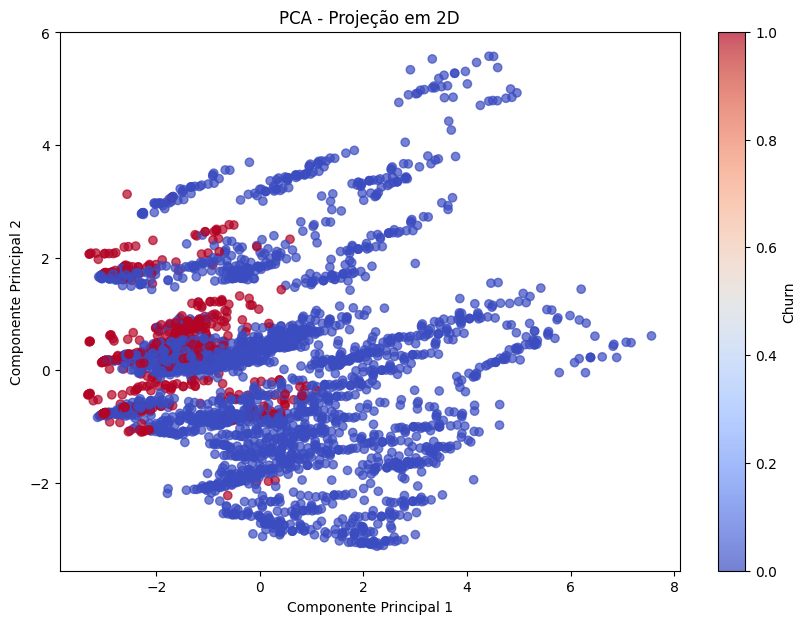

In [9]:
#Separar atributos e variável alvo
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

#Padronização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Aplicar PCA para 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Scatter plot
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA - Projeção em 2D")

plt.colorbar(label='Churn')

plt.show()

Existe uma separação parcial pois a classe 0 (clientes que não cancelaram o serviço) aparece distribuída em uma área maior, enquanto a classe 1 (clientes que cancelaram) está mais concentrada em regiões específicas. As classes não estão completamente separadas portanto não temos dados suficientes para uma separação perfeita.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [10]:
#Separar variáveis de entrada e variável alvo
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

#Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Padronização dos dados
scaler = StandardScaler()

#Ajustar apenas no treino
X_train_scaled = scaler.fit_transform(X_train)

#Aplicar no teste
X_test_scaled = scaler.transform(X_test)

#Exibir dimensões
print("Treino:", X_train_scaled.shape)
print("Teste:", X_test_scaled.shape)

Treino: (2520, 13)
Teste: (630, 13)


A padronização é importante porque os atributos do dataset possuem escalas diferentes, como idade, frequência de uso e valor do cliente. Sem a padronização, atributos com valores maiores podem ter mais influência no modelo do que atributos com valores menores, prejudicando o desempenho de algoritmos sensíveis à escala dos dados.

O StandardScaler transforma os dados para que os atributos tenham média próxima de 0 e desvio padrão igual a 1, colocando todas as variáveis na mesma escala.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [12]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Treinar
model.fit(X_train_scaled, y_train)

# Verificar convergência
print("Iterações utilizadas:", model.n_iter_[0])
print("Máximo permitido:", model.max_iter)

if model.n_iter_[0] < model.max_iter:
    print("O modelo convergiu corretamente.")
else:
    print("O modelo pode não ter convergido.")

Iterações utilizadas: 42
Máximo permitido: 1000
O modelo convergiu corretamente.


Neste problema, o modelo de regressão logística tem o papel de classificar os clientes entre aqueles que irão cancelar o serviço Churn = 1 e aqueles que não irão cancelar Churn = 0. O modelo aprende padrões existentes nos dados, relacionando os atributos dos clientes como número de reclamações, frequência de uso, tempo de utilização e valor do cliente com a variável alvo. A partir dessas relações, o modelo calcula a probabilidade de cada cliente pertencer a uma das classes.

Assim, a regressão logística aprende quais características aumentam ou diminuem a chance de churn, permitindo prever o comportamento de novos clientes com base nos padrões identificados no conjunto de treino.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [17]:
# Calcular probabilidades previstas
y_proba = model.predict_proba(X_test_scaled)

# Exibir algumas probabilidades
print(y_proba[:10])

[[9.98819220e-01 1.18078042e-03]
 [9.99954113e-01 4.58869561e-05]
 [9.74259483e-01 2.57405165e-02]
 [9.99517602e-01 4.82398265e-04]
 [9.98645143e-01 1.35485663e-03]
 [9.97154922e-01 2.84507844e-03]
 [9.91458577e-01 8.54142300e-03]
 [9.91454963e-01 8.54503750e-03]
 [9.87024986e-01 1.29750142e-02]
 [5.90190333e-01 4.09809667e-01]]


As probabilidades previstas mostram a confiança do modelo para cada classe. Em cada linha, a primeira coluna representa a probabilidade do cliente pertencer à classe 0 (não cancelar o serviço) e a segunda coluna representa a probabilidade da classe 1 (cancelar o serviço).

Nos resultados obtidos, a maioria das previsões apresenta valores muito próximos de 1 para a classe 0, como [0.9988, 0.0012] e [0.9999, 0.00004], indicando que o modelo possui alta confiança de que esses clientes não irão cancelar o serviço.

Já a última previsão [0.5901, 0.4098] apresenta probabilidades mais próximas entre si, indicando menor confiança do modelo na classificação, pois existe maior incerteza entre as duas classes.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [18]:
# Probabilidades da classe 1
y_scores = y_proba[:, 1]

# Classificações com limiar 0.5
y_pred_05 = (y_scores >= 0.5).astype(int)

# Classificações com limiar 0.7
y_pred_07 = (y_scores >= 0.7).astype(int)

# Matrizes de confusão
cm_05 = confusion_matrix(y_test, y_pred_05)
cm_07 = confusion_matrix(y_test, y_pred_07)

print("Matriz de confusão - limiar 0.5")
print(cm_05)

print("\nMatriz de confusão - limiar 0.7")
print(cm_07)

Matriz de confusão - limiar 0.5
[[504  16]
 [ 66  44]]

Matriz de confusão - limiar 0.7
[[514   6]
 [ 74  36]]


Ao aumentar o limiar de 0.5 para 0.7, o modelo se torna mais rigoroso para classificar um cliente como churn. Com isso, a quantidade de falsos positivos diminuiu (de 16 para 6), porém a quantidade de falsos negativos aumentou (de 66 para 74). Isso mostra que limiares maiores tornam o modelo mais conservador, reduzindo alarmes falsos, mas também aumentando a chance de deixar de identificar clientes que realmente cancelariam o serviço.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

#Função para exibir métricas
def avaliar_modelo(y_true, y_pred, limiar):
    print(f"\nLimiar: {limiar}")

    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Precisão:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))

    print("Matriz de confusão:")
    print(confusion_matrix(y_true, y_pred))

#Avaliação para limiar 0.5
avaliar_modelo(y_test, y_pred_05, 0.5)

#Avaliação para limiar 0.7
avaliar_modelo(y_test, y_pred_07, 0.7)


Limiar: 0.5
Acurácia: 0.8698412698412699
Precisão: 0.7333333333333333
Recall: 0.4
F1-score: 0.5176470588235295
Matriz de confusão:
[[504  16]
 [ 66  44]]

Limiar: 0.7
Acurácia: 0.873015873015873
Precisão: 0.8571428571428571
Recall: 0.32727272727272727
F1-score: 0.47368421052631576
Matriz de confusão:
[[514   6]
 [ 74  36]]


Comparando os dois limiares, observa-se que o aumento do limiar de 0.5 para 0.7 aumentou a precisão do modelo (de 0.73 para 0.86), pois houve redução dos falsos positivos (de 16 para 6). Porém, o recall diminuiu (de 0.40 para 0.33), já que os falsos negativos aumentaram (de 66 para 74).

A métrica mais impactada foi o recall, indicando que o modelo passou a identificar menos clientes que realmente cancelariam o serviço. Isso demonstra o trade-off entre precisão e recall: ao tornar o modelo mais rigoroso para prever churn, ele reduz alarmes falsos, mas também deixa de detectar mais casos positivos reais.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

O dataset Covertype pertence ao domínio de ecologia e sensoriamento geográfico, sendo utilizado em problemas de classificação de cobertura florestal. Seu principal objetivo é prever o tipo de cobertura vegetal (Cover_Type) de áreas florestais a partir apenas de variáveis cartográficas. A base contém informações de células de terreno de 30x30 metros localizadas em áreas florestais do norte do Colorado, incluindo atributos como elevação, inclinação, orientação do terreno, distâncias até hidrografia, estradas e pontos de incêndio, além de variáveis binárias relacionadas ao tipo de solo e áreas de preservação ambiental. O problema é de classificação multiclasse, envolvendo sete diferentes tipos de cobertura florestal.

In [20]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [21]:
#Exibir primeiras linhas
display(df.head())

#Dimensões do dataframe
print("Dimensões:", df.shape)

#Variável alvo
TARGET_COLUMN = "Cover_Type"
print("Variável alvo:", TARGET_COLUMN)

#Valores únicos da variável alvo
print("Valores únicos:", df[TARGET_COLUMN].unique())

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


Dimensões: (58101, 55)
Variável alvo: Cover_Type
Valores únicos: [1 2 3 5 6 7 4]


In [ ]:
TARGET_COLUMN = "Cover_Type"

Com base nos resultados obtidos, o dataset possui 58.101 amostras e 55 atributos no total. A variável alvo do problema é Cover_Type, responsável por representar o tipo de cobertura florestal da região analisada. Observando os valores únicos da variável alvo ([1 2 3 5 6 7 4]), conclui-se que o problema não é de classificação binária, pois existem sete classes diferentes possíveis. Portanto, trata-se de um problema de classificação multiclasse, no qual o modelo deve prever qual tipo de cobertura florestal pertence a cada amostra do dataset.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

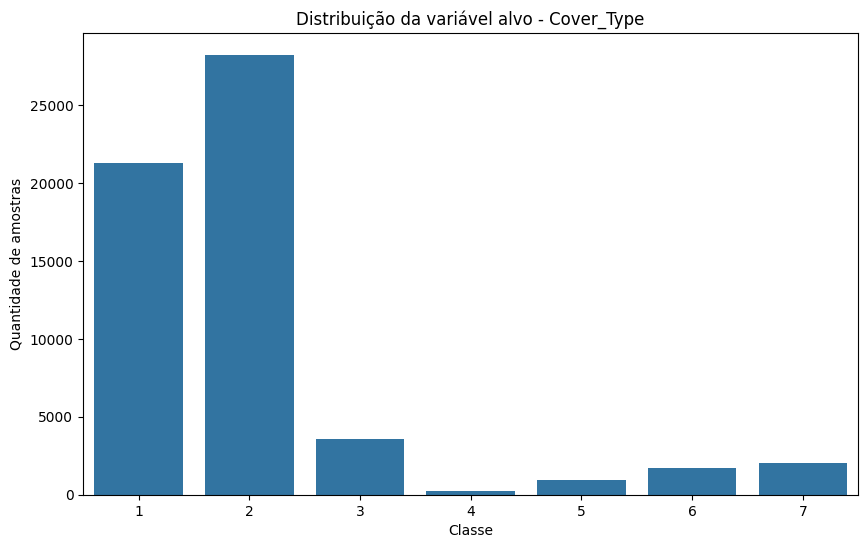

Cover_Type
2    28248
1    21297
3     3607
7     2052
6     1706
5      932
4      259
Name: count, dtype: int64


In [22]:
#Contagem das classes
plt.figure(figsize=(10,6))

sns.countplot(x=df[TARGET_COLUMN])

plt.title("Distribuição da variável alvo - Cover_Type")
plt.xlabel("Classe")
plt.ylabel("Quantidade de amostras")

plt.show()

#Exibir contagem das classes
print(df[TARGET_COLUMN].value_counts())

Com base na distribuição da variável alvo Cover_Type, observa-se que o dataset é desbalanceado. As classes 1 e 2 possuem uma quantidade muito maior de amostras (21297 e 28248, respectivamente), enquanto classes como 4, 5, 6 e 7 possuem bem menos registros, principalmente a classe 4, com apenas 259 amostras.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

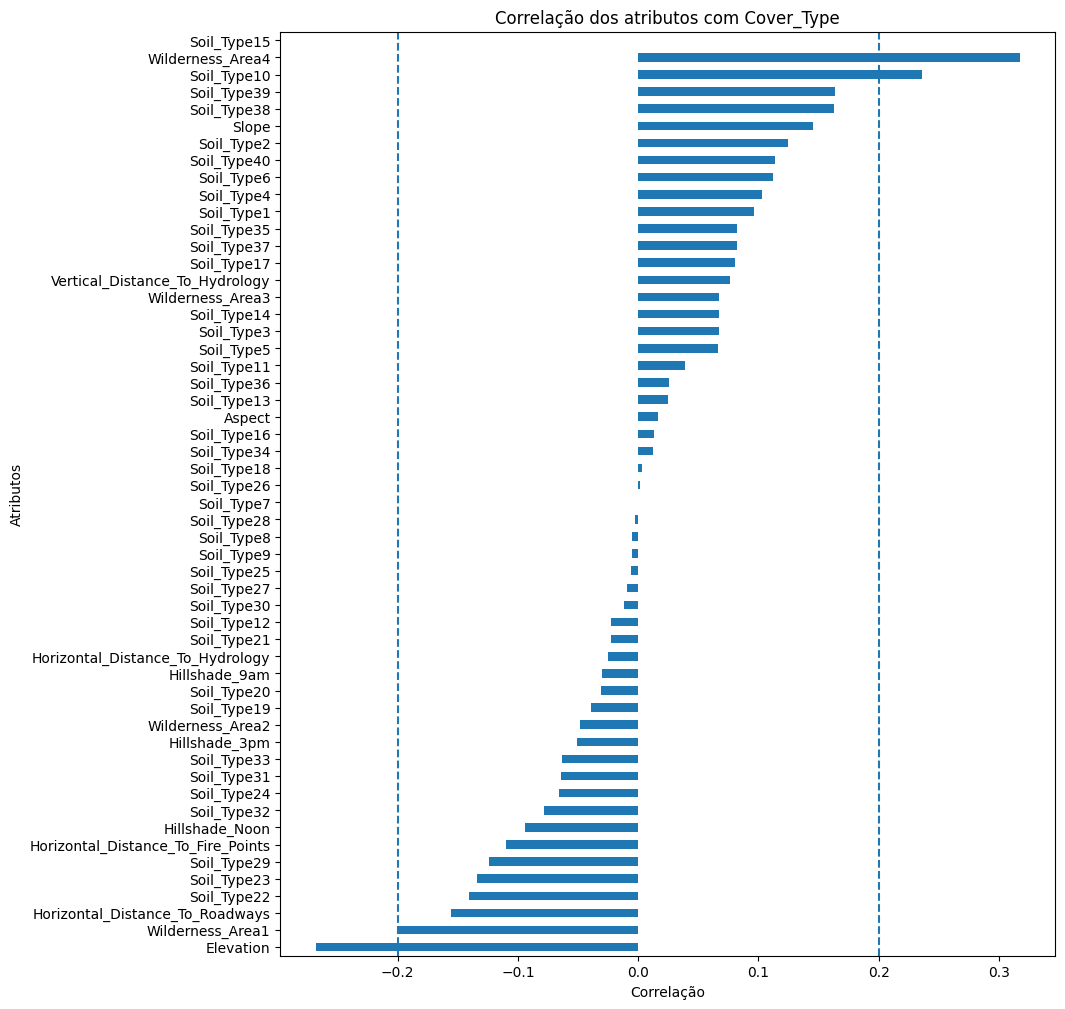

Elevation                            -0.268264
Wilderness_Area1                     -0.200715
Horizontal_Distance_To_Roadways      -0.155258
Soil_Type22                          -0.140253
Soil_Type23                          -0.133668
Soil_Type29                          -0.123732
Horizontal_Distance_To_Fire_Points   -0.109868
Hillshade_Noon                       -0.094159
Soil_Type32                          -0.078483
Soil_Type24                          -0.065993
Soil_Type31                          -0.064168
Soil_Type33                          -0.063686
Hillshade_3pm                        -0.050833
Wilderness_Area2                     -0.048265
Soil_Type19                          -0.039402
Soil_Type20                          -0.030760
Hillshade_9am                        -0.029857
Horizontal_Distance_To_Hydrology     -0.024854
Soil_Type21                          -0.022818
Soil_Type12                          -0.022214
Soil_Type30                          -0.011948
Soil_Type27  

In [23]:
#Correlação com a variável alvo
corr_target = df.corr()["Cover_Type"].drop("Cover_Type")

#Ordenar valores
corr_sorted = corr_target.sort_values()

#Plotar gráfico
plt.figure(figsize=(10,12))

corr_sorted.plot(kind='barh')

#Linhas de referência
plt.axvline(x=0.2, linestyle='--')
plt.axvline(x=-0.2, linestyle='--')

plt.title("Correlação dos atributos com Cover_Type")
plt.xlabel("Correlação")
plt.ylabel("Atributos")

plt.show()

#Exibir valores numéricos
print(corr_sorted)

Com base nas correlações obtidas, as variáveis que apresentaram maior relação com a variável alvo Cover_Type foram Wilderness_Area4 (r ≈ 0.32), Soil_Type10 (r ≈ 0.24) e Elevation (r ≈ -0.27). Esses atributos ultrapassaram o limiar de   |r| = 0.2, indicando correlações moderadas e maior relevância potencial para o modelo de classificação. Portanto, variáveis relacionadas à altitude (Elevation), áreas de vegetação (Wilderness_Area) e tipos de solo (Soil_Type) parecem ser as mais importantes para prever o tipo de cobertura florestal no dataset.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

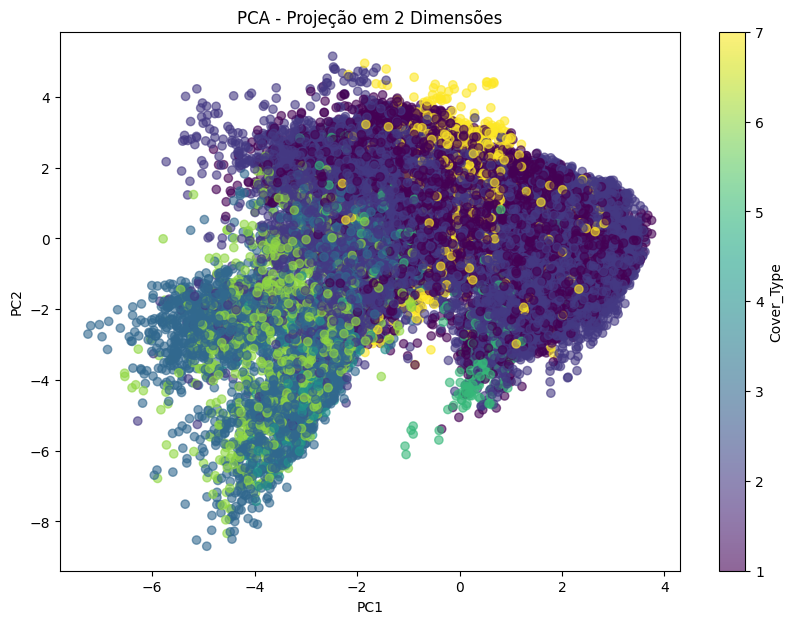

In [24]:
from sklearn.decomposition import PCA

#Separar X e y
X = df.drop(columns=["Cover_Type"])
y = df["Cover_Type"]

#Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#PCA para 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Scatter plot
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Projeção em 2 Dimensões")

plt.colorbar(scatter, label="Cover_Type")

plt.show()

Com base na projeção gerada pelo PCA, existe apenas uma separação parcial entre as classes do dataset. Algumas regiões apresentam maior concentração de determinadas classes, indicando que certos tipos de cobertura florestal possuem características relativamente distintas. há uma forte sobreposição entre muitos grupos ao longo das duas componentes principais (PC1 e PC2), especialmente entre as classes mais frequentes. Isso mostra que as duas primeiras componentes não são suficientes para separar completamente todas as classes do problema.Portanto, o problema apresenta elevada complexidade e baixa separabilidade linear em duas dimensões, sugerindo que modelos mais robustos ou o uso de mais componentes principais podem ser necessários para melhorar a diferenciação entre os diferentes tipos de cobertura florestal.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>